In [1]:
# ── 셀 1: 데이터 로드 ──────────────────────────────
# WM-811K: 811,457개 웨이퍼 맵 데이터
# 불량 패턴 9가지 분류 목표
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_pickle('LSWMD.pkl')
print(df.shape)
print(df.columns.tolist())
df.head()

# 라이브러리 불러오기, LSWMD.pk1 파일 불러오기, df.shape으로 행/열 개수 확인, 컬럼 이름 확인, head()로 첫 5행 출력 
# 811,456행, 6개 칼럼 /waferMap : 웨이퍼 맵 이미지 데이터 (숫자 배열)/ failuretype: 불량 패턴 종류(예측할 라벨)
# triantestlabel : 학습/테스트 구분

(811457, 6)
['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [2]:
# ── 셀 2: 기본 현황 파악 ──────────────────────────
# failureType 값 추출 (중첩 리스트 형태라 변환 필요)
df['failureType'] = df['failureType'].apply(lambda x: x[0][0] if len(x) > 0 else 'none')
print(df['failureType'].value_counts())
print("\nwaferMap 샘플 크기:", df['waferMap'].iloc[0].shape)

#failuretype [[none]] 중첩 리스트를 단순 텍스트 변환
#none > 정상 웨이퍼 / 45행 48열 숫자 배열

failureType
none         785938
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

waferMap 샘플 크기: (45, 48)


C:\Users\jinhy\AppData\Local\Temp\ipykernel_22580\289589718.py:15: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinhy\AppData\Local\Temp\ipykernel_22580\289589718.py:15: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinhy\AppData\Local\Temp\ipykernel_22580\289589718.py:15: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinhy\AppData\Local\Temp\ipykernel_22580\289589718.py:15: UserWarning: Glyph 53556 (\N{HANGUL SYLLABLE TEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinhy\AppData\Local\Temp\ipykernel_22580\289589718.py:15: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jinhy\AppData\Local\Temp\ipykernel_22580\289589718.py:15: UserWarning: Glyph 50920 (\N{HANGUL SYLLABLE WE}) missing from 

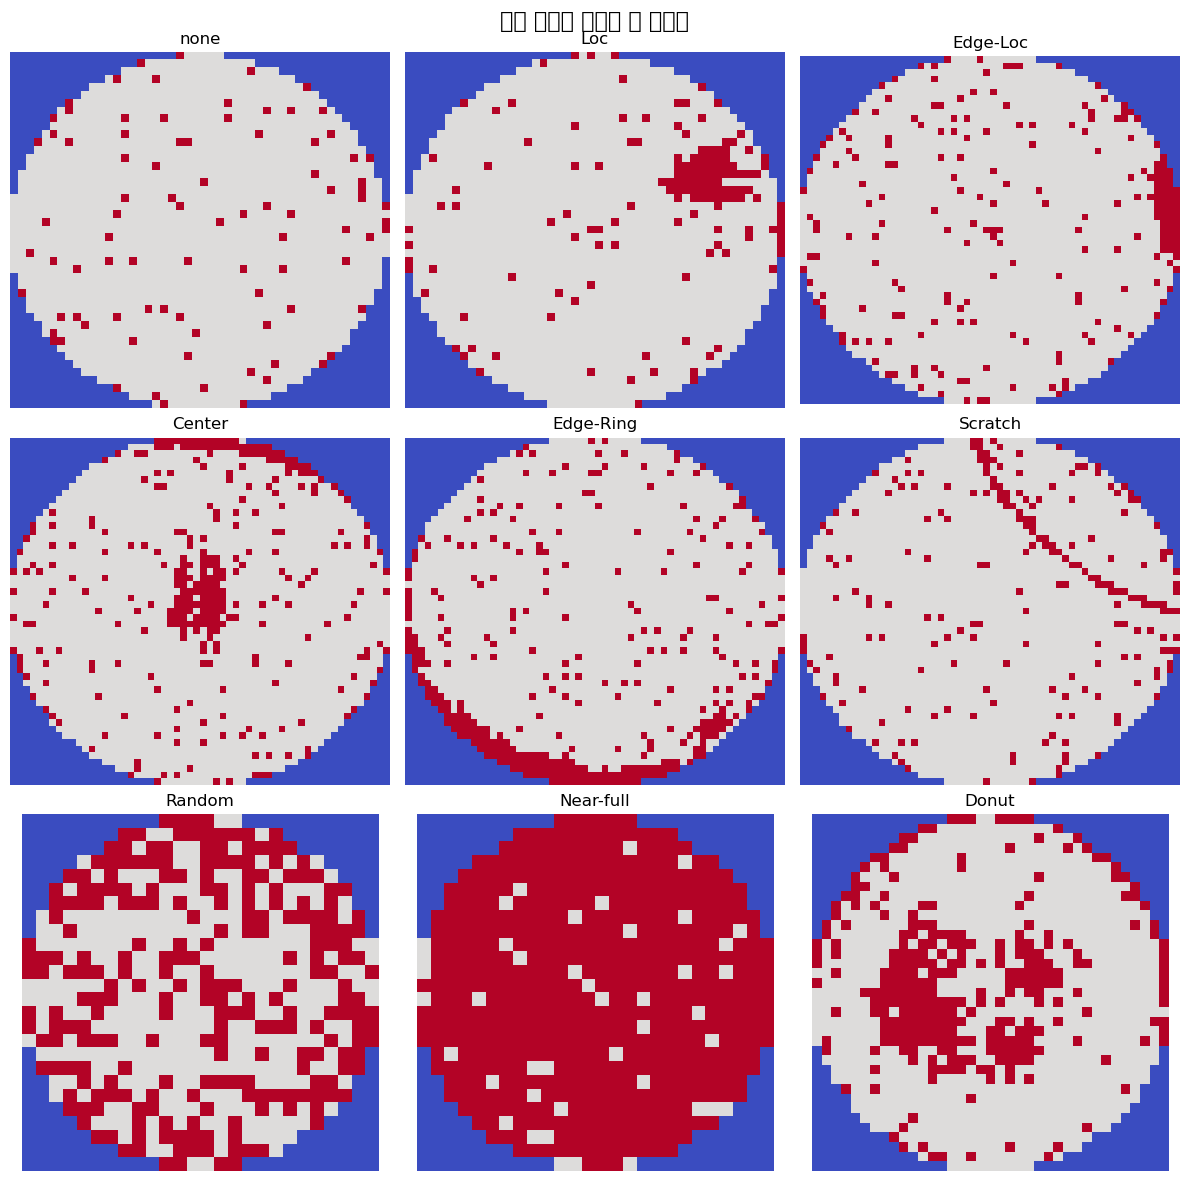

In [3]:
# ── 셀 3: 패턴별 웨이퍼 맵 시각화 ─────────────────
# 각 불량 패턴이 실제로 어떻게 생겼는지 확인
# 웨이퍼 맵: 0=빈공간, 1=양품 다이, 2=불량 다이
patterns = df['failureType'].unique()
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, pattern in enumerate(patterns):
    sample = df[df['failureType'] == pattern]['waferMap'].iloc[0]
    axes[i].imshow(sample, cmap='coolwarm')
    axes[i].set_title(pattern)
    axes[i].axis('off')

plt.suptitle('불량 패턴별 웨이퍼 맵 시각화', fontsize=16)
plt.tight_layout()
plt.show()

# 불량 패턴 시각화
# 패턴 마다 공정 원인 다름

In [4]:
# ── 셀 4: 전처리 ───────────────────────────────────
# 불량 패턴만 추출 (none 제외)
# 웨이퍼 맵을 1차원 배열로 변환 (모델 입력용)
# 크기가 다른 웨이퍼 맵을 동일 크기로 맞춤
df_fault = df[df['failureType'] != 'none'].copy()
print(f"불량 샘플 수: {len(df_fault)}")
print(f"패턴 종류: {df_fault['failureType'].value_counts()}")

# Edge-Ring 가장 많음, Near-full 가장 적음

불량 샘플 수: 25519
패턴 종류: failureType
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


In [5]:
# ── 셀 5: 웨이퍼 맵 크기 통일 및 변환 ──────────────
# 모든 웨이퍼 맵을 동일 크기(32x32)로 리사이즈
# 모델 입력을 위해 1차원 배열로 변환
from skimage.transform import resize

def resize_wafer(wafer_map, size=(32, 32)):
    return resize(wafer_map, size, anti_aliasing=False)

X = np.array([resize_wafer(w).flatten() for w in df_fault['waferMap']])
y = df_fault['failureType'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (25519, 1024)
y shape: (25519,)


In [6]:
# ── 셀 6: 학습/테스트 분리 및 모델 학습 ─────────────
# 불량 패턴 분류 → 다중 클래스 문제
# SECOM과 달리 클래스가 8개라 class_weight='balanced' 사용
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Center       0.93      0.95      0.94       859
       Donut       0.89      0.69      0.78       111
    Edge-Loc       0.69      0.93      0.80      1038
   Edge-Ring       0.99      0.95      0.97      1936
         Loc       0.71      0.63      0.67       719
   Near-full       1.00      0.77      0.87        30
      Random       0.90      0.80      0.84       173
     Scratch       0.56      0.16      0.25       238

    accuracy                           0.85      5104
   macro avg       0.83      0.74      0.76      5104
weighted avg       0.85      0.85      0.84      5104



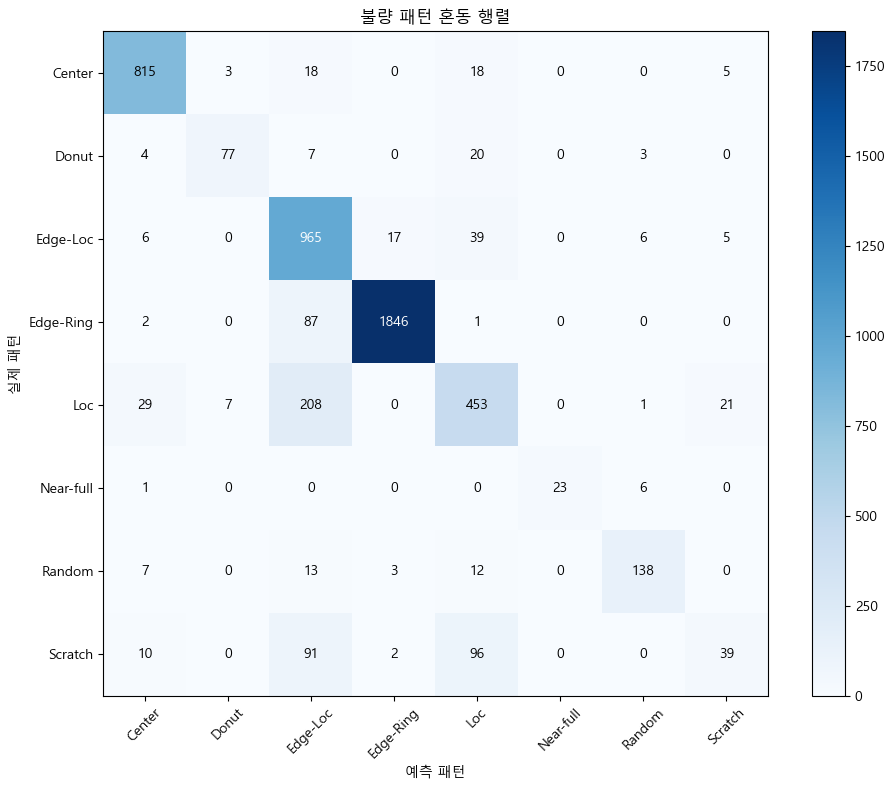

In [7]:
# ── 셀 7: 혼동 행렬 시각화 ──────────────────────────
# 어떤 패턴을 어떤 패턴으로 잘못 분류하는지 확인
# 대각선: 정확히 분류, 나머지: 오분류
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'

labels = sorted(df_fault['failureType'].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)
plt.xlabel('예측 패턴')
plt.ylabel('실제 패턴')
plt.title('불량 패턴 혼동 행렬')

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

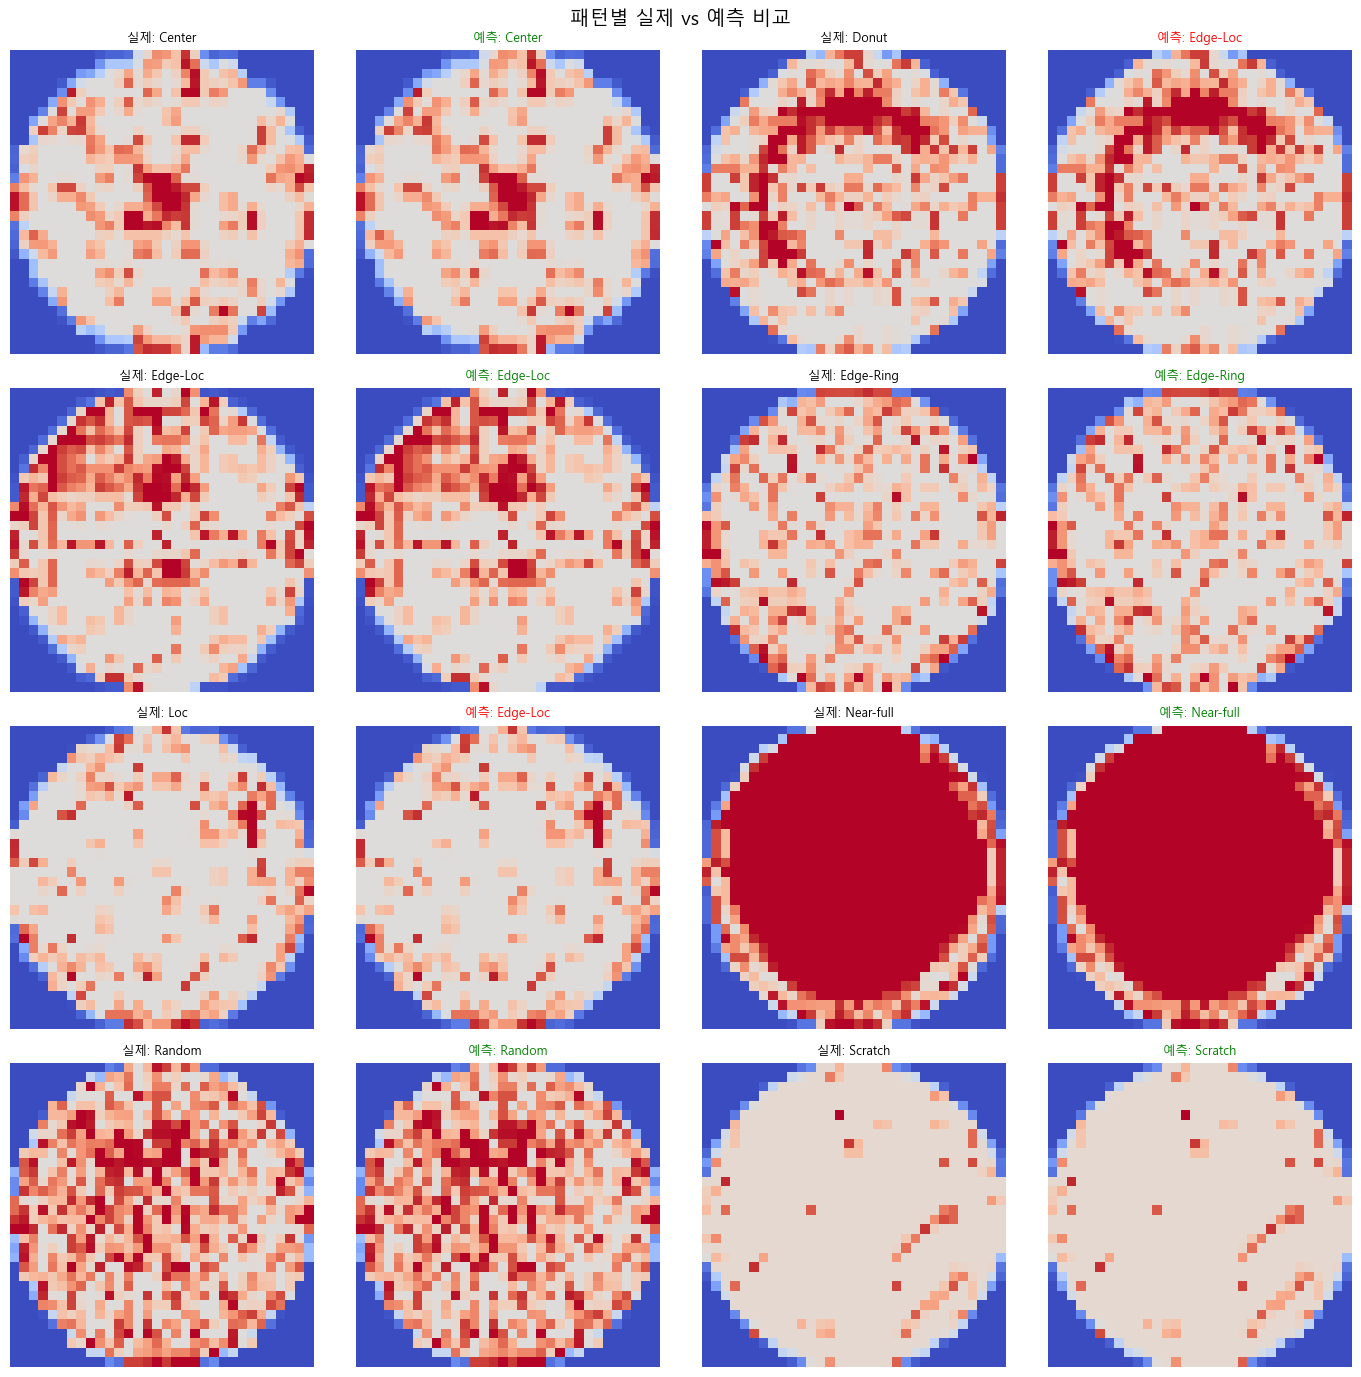

In [8]:
# ── 셀 8: 예측 결과 시각화 ──────────────────────────
# 각 패턴별로 실제 vs 예측 비교
# 맞춘 것(초록), 틀린 것(빨강)으로 표시
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.flatten()

for i, pattern in enumerate(labels):
    idx = np.where(y_test == pattern)[0][0]
    wafer = X_test[idx].reshape(32, 32)
    pred = y_pred[idx]
    actual = y_test[idx]
    color = 'green' if pred == actual else 'red'

    axes[i*2].imshow(wafer, cmap='coolwarm')
    axes[i*2].set_title(f'실제: {actual}', color='black', fontsize=9)
    axes[i*2].axis('off')

    axes[i*2+1].imshow(wafer, cmap='coolwarm')
    axes[i*2+1].set_title(f'예측: {pred}', color=color, fontsize=9)
    axes[i*2+1].axis('off')

plt.suptitle('패턴별 실제 vs 예측 비교', fontsize=14)
plt.tight_layout()
plt.show()

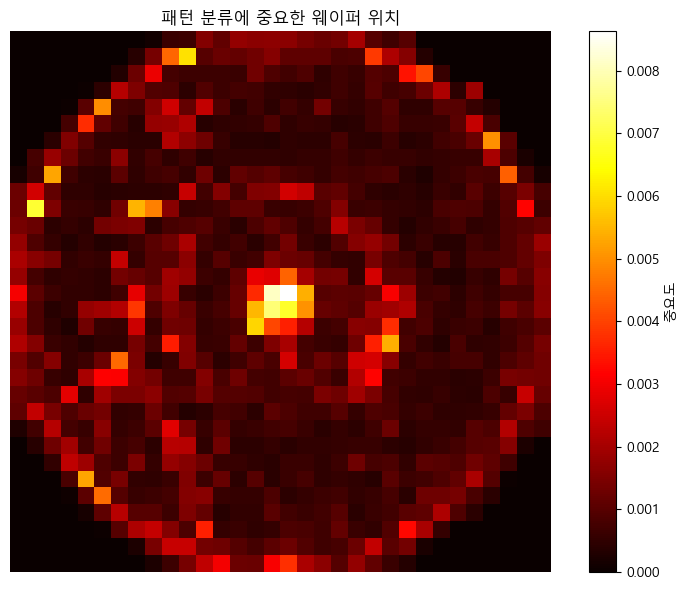

In [9]:
# ── 셀 9: 피처 중요도 히트맵 ────────────────────────
# 1024개 픽셀 중 어느 위치가 패턴 분류에 중요한지 시각화
# 밝을수록 분류에 중요한 위치
importances = model.feature_importances_
importance_map = importances.reshape(32, 32)

plt.figure(figsize=(8, 6))
plt.imshow(importance_map, cmap='hot')
plt.colorbar(label='중요도')
plt.title('패턴 분류에 중요한 웨이퍼 위치')
plt.axis('off')
plt.tight_layout()
plt.show()

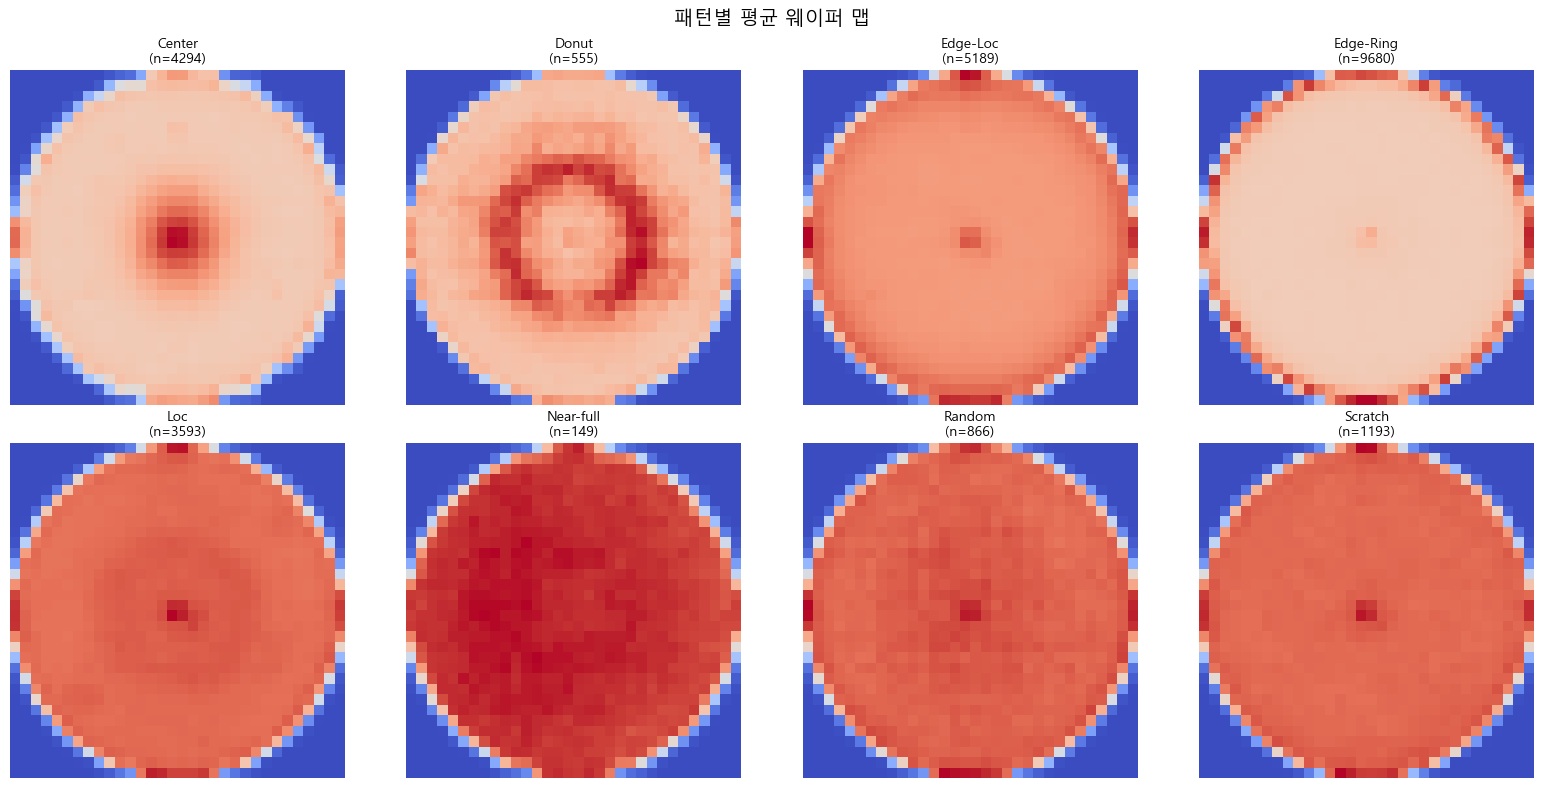

In [10]:
# ── 셀 10: 패턴별 평균 웨이퍼 맵 ────────────────────
# 각 패턴의 "전형적인 모습"을 평균으로 시각화
# 개별 샘플의 노이즈를 제거하고 패턴 특징을 부각
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, pattern in enumerate(labels):
    mask = y == pattern
    mean_map = X[mask].mean(axis=0).reshape(32, 32)
    axes[i].imshow(mean_map, cmap='coolwarm')
    axes[i].set_title(f'{pattern}\n(n={mask.sum()})', fontsize=10)
    axes[i].axis('off')

plt.suptitle('패턴별 평균 웨이퍼 맵', fontsize=14)
plt.tight_layout()
plt.show()

전체 오분류 수: 748개 / 5104개

오분류 상위 조합:
실제         예측      
Loc        Edge-Loc    208
Scratch    Loc          96
           Edge-Loc     91
Edge-Ring  Edge-Loc     87
Edge-Loc   Loc          39
Loc        Center       29
           Scratch      21
Donut      Loc          20
Center     Edge-Loc     18
           Loc          18
dtype: int64


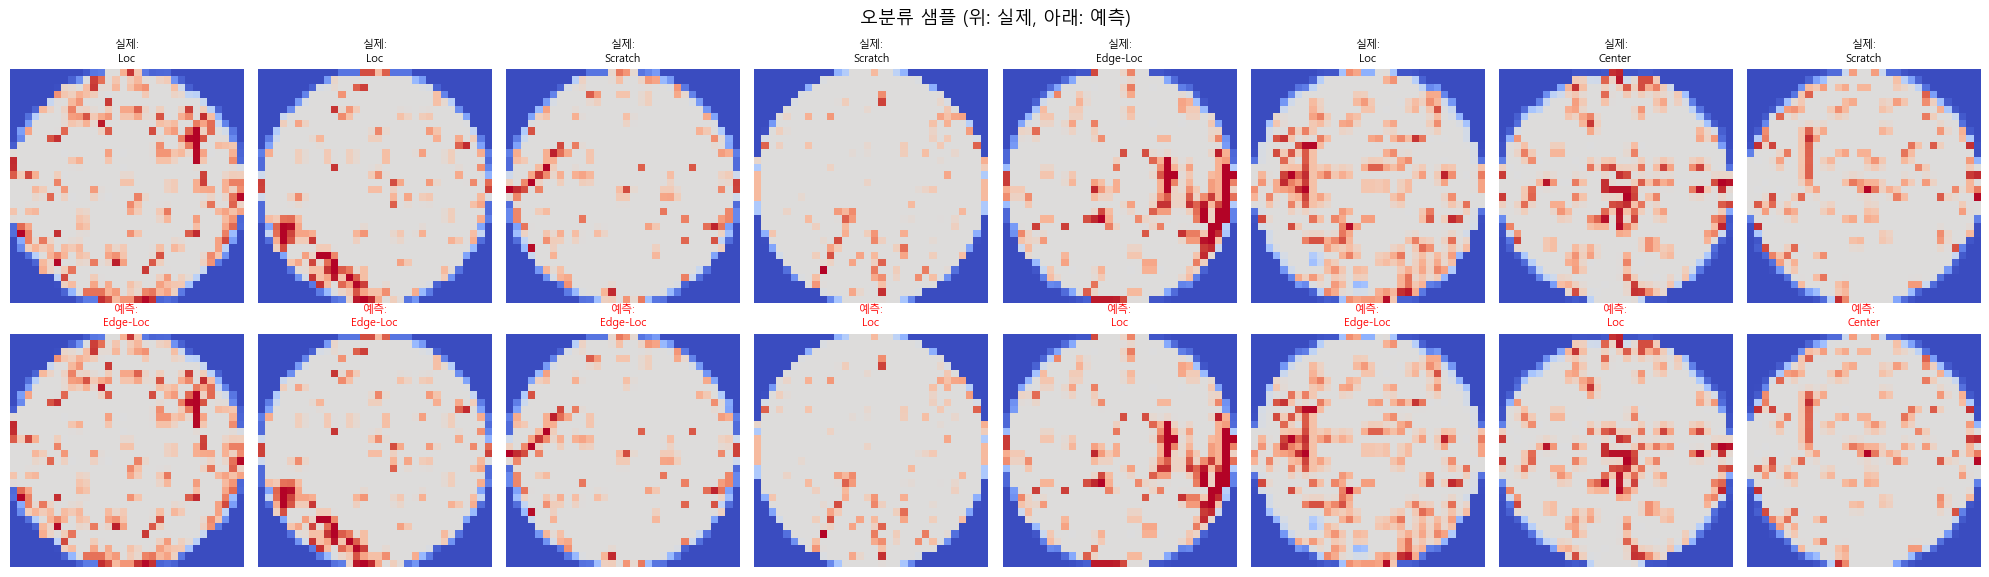

In [11]:
# ── 셀 11: 오분류 샘플 분석 ──────────────────────────
# 틀린 샘플만 모아서 실제 vs 예측 비교
# 왜 틀렸는지 시각적으로 확인
wrong_idx = np.where(y_pred != y_test)[0]
print(f"전체 오분류 수: {len(wrong_idx)}개 / {len(y_test)}개")

# 오분류 패턴 조합 상위 5개
import pandas as pd
wrong_df = pd.DataFrame({
    '실제': y_test[wrong_idx],
    '예측': y_pred[wrong_idx]
})
print("\n오분류 상위 조합:")
print(wrong_df.groupby(['실제', '예측']).size().sort_values(ascending=False).head(10))

# 오분류 샘플 시각화 (상위 8개)
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, idx in enumerate(wrong_idx[:8]):
    axes[0, i].imshow(X_test[idx].reshape(32, 32), cmap='coolwarm')
    axes[0, i].set_title(f'실제:\n{y_test[idx]}', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(X_test[idx].reshape(32, 32), cmap='coolwarm')
    axes[1, i].set_title(f'예측:\n{y_pred[idx]}', fontsize=8, color='red')
    axes[1, i].axis('off')

plt.suptitle('오분류 샘플 (위: 실제, 아래: 예측)', fontsize=13)
plt.tight_layout()
plt.show()

해상도 16x16 → 정확도: 0.822
해상도 32x32 → 정확도: 0.845
해상도 48x48 → 정확도: 0.847
해상도 64x64 → 정확도: 0.846


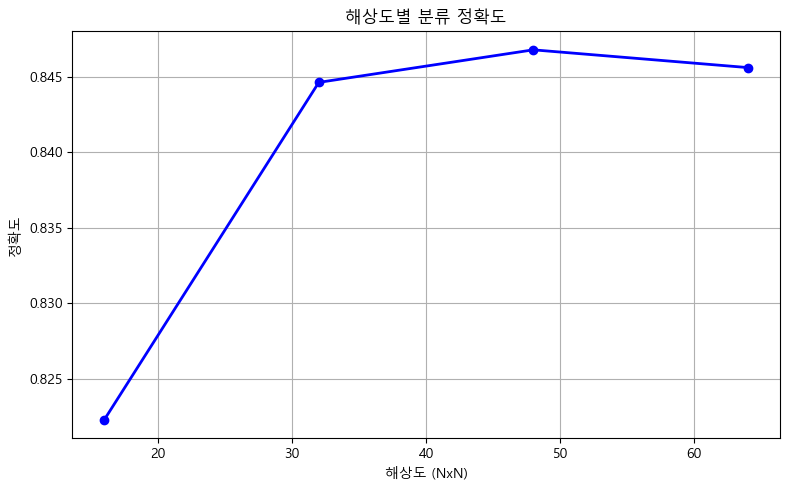

In [12]:
# ── 셀 12: 해상도별 성능 비교 ────────────────────────
# 32x32 vs 48x48 vs 64x64 크기별 정확도 변화
# 해상도 높을수록 Scratch 같은 선형 패턴 특징이 보존됨
from sklearn.metrics import accuracy_score

sizes = [16, 32, 48, 64]
accuracies = []

for size in sizes:
    X_temp = np.array([resize(w, (size, size), anti_aliasing=False).flatten()
                       for w in df_fault['waferMap']])
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_temp, y, test_size=0.2, random_state=42, stratify=y
    )
    rf_temp = RandomForestClassifier(
        n_estimators=50, class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf_temp.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, rf_temp.predict(X_te))
    accuracies.append(acc)
    print(f"해상도 {size}x{size} → 정확도: {acc:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(sizes, accuracies, 'b-o', linewidth=2)
plt.xlabel('해상도 (NxN)')
plt.ylabel('정확도')
plt.title('해상도별 분류 정확도')
plt.grid(True)
plt.tight_layout()
plt.show()

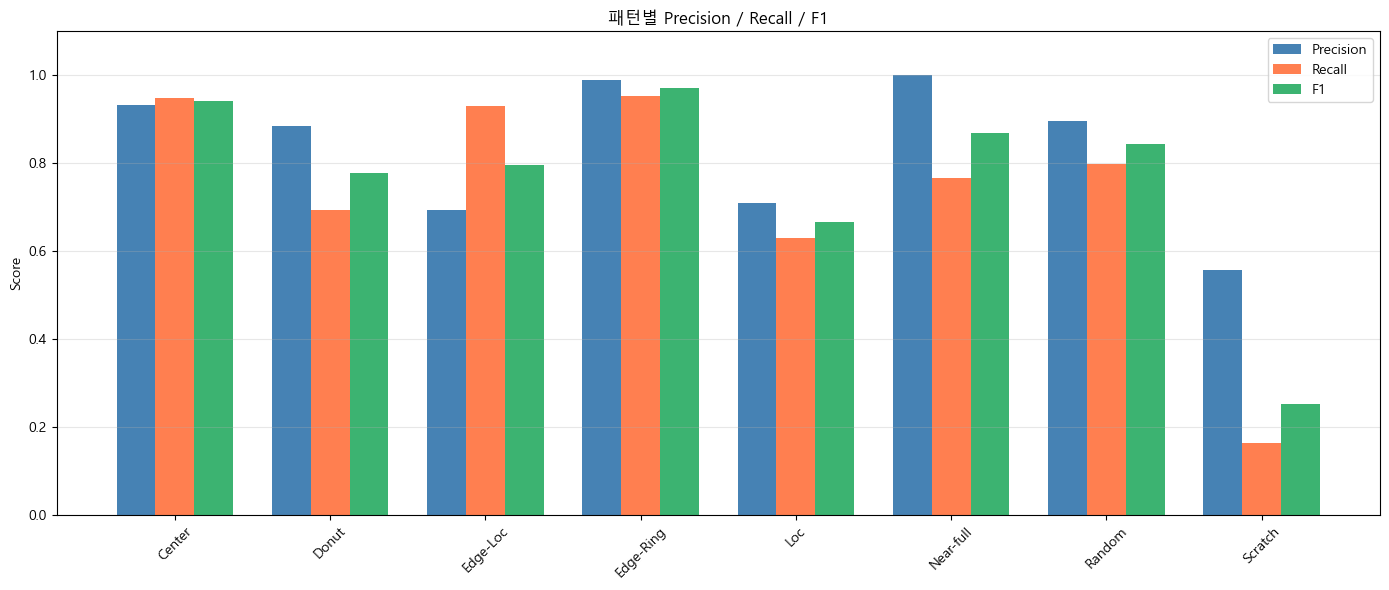

In [14]:
# ── 셀 13: 패턴별 Precision/Recall/F1 막대그래프 ──────
# 텍스트로만 나오던 성능 지표를 시각화
# 어떤 패턴이 강하고 약한지 한눈에 비교
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=labels
)

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - width, precision, width, label='Precision', color='steelblue')
plt.bar(x, recall, width, label='Recall', color='coral')
plt.bar(x + width, f1, width, label='F1', color='mediumseagreen')

plt.xticks(x, labels, rotation=45)
plt.ylabel('Score')
plt.title('패턴별 Precision / Recall / F1')
plt.legend()
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

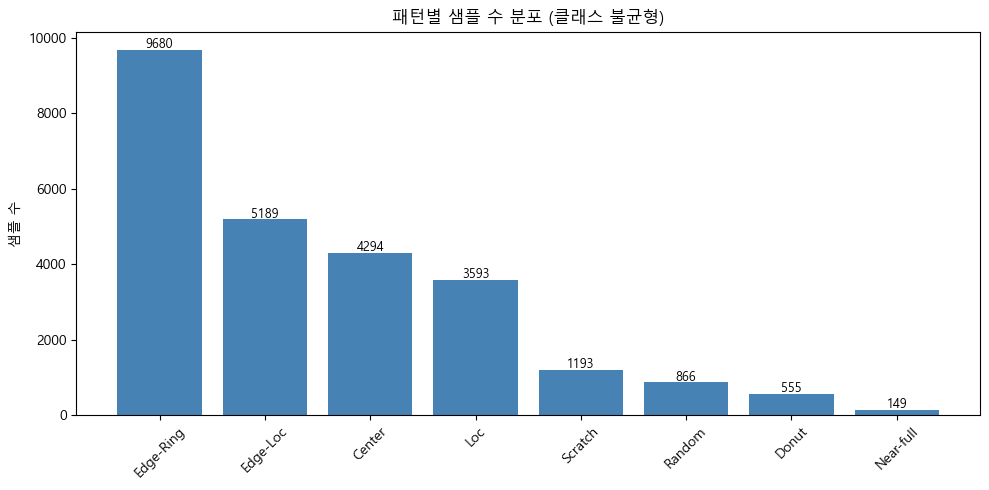

In [15]:
# ── 셀 14: 클래스 분포 시각화 ────────────────────────
# 패턴별 샘플 수 차이 시각화
# Near-full 149개 vs Edge-Ring 9680개 → 65배 차이
counts = df_fault['failureType'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(counts.index, counts.values, color='steelblue')
plt.xticks(rotation=45)
plt.ylabel('샘플 수')
plt.title('패턴별 샘플 수 분포 (클래스 불균형)')

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.show()